## Analysing first principle results

In [1]:
import pandas as pd
import json
import os
import numpy as np; np.random.seed(42)
from glob import glob
from tqdm import tqdm
import seaborn as sns
import pdb

# !pip install textalloc
import textalloc as ta

import sys; sys.path.append('..')
from pareto_utils import front

import matplotlib.pyplot as plt
import matplotlib

matplotlib.rc('pdf', fonttype=42)
matplotlib.rc('ps', fonttype=42)

params = {'mathtext.default': 'regular' }          
plt.rcParams.update(params)

sns.set(font_scale=1.25, style='whitegrid')
sns.set(palette='magma')
sns.set_style("whitegrid")

rdir  = '../../results/first-principles-tuning/'
figdir = f'../figs/first-principles-tuning/'
ddir = '../../datasets/firstprinciples'

# This one also works with the blackbox!
# rdir  = '../../results/black-box-tuning/'
# figdir = f'../figs/black-box-tuning/'
# ddir = '../../datasets/blackbox'

def save(name='tmp',h=None):
    name = name.strip().replace(' ','-').replace('%','pct')
    if h == None:
        h = plt.gcf()

    h.tight_layout()

    print('saving',figdir+'/'+name+'.pdf')

    if not os.path.exists(figdir):
        os.makedirs(figdir)

    plt.savefig(figdir+'/'+name+'.pdf', bbox_inches='tight')
    plt.savefig(figdir+'/'+name+'.png', bbox_inches='tight')

# read data from feather

In [2]:
df_results = pd.read_feather(rdir+'results.feather')

print('mean trial count:')
print(df_results.groupby('algorithm')['dataset'].count().sort_values()
      / df_results.dataset.nunique())

mean trial count:
algorithm
E2E                    5.230769
NeSymRes               5.461538
TPSR                   5.461538
GP-GOMEA              11.692308
BSR                   23.769231
FEAT                  28.846154
TIR                   29.461538
EQL                   29.923077
Rils-Rols             29.923077
Brush                 30.000000
Bingo                 30.000000
FFX                   30.000000
EPLEX                 30.000000
AFP_FE                30.000000
AFP_EHC               30.000000
AFP                   30.000000
Genetic Engine hc     30.000000
Genetic Engine 1p1    30.000000
Genetic Engine        30.000000
GPZGD                 30.000000
Operon                30.000000
PS-Tree               30.000000
ITEA                  30.000000
Genetic Engine rs     30.000000
QLattice              30.000000
PYSR                  30.000000
gplearn               30.000000
Name: dataset, dtype: float64


# Pareto plot

Plot the method results as trade-offs between accuracy and simplicity

In [3]:
def bootstrap(val, n = 1000, fn=np.mean):
    val_samples = []
    for i in range(n):
        sample = np.random.randint(0,len(val)-1, size=len(val))
        val_samples.append( fn(val[sample]) )

    m = np.mean(val_samples)
    sd = np.std(val_samples)
    ci_upper  = np.quantile(val_samples,0.95)
    ci_lower  = np.quantile(val_samples,0.05)

    return m, sd, ci_upper,ci_lower

In [4]:
import numpy as np

fs_data = {
    # === Bode ===
    'first_principles_bode': {
        'model_size': 6,
        'r2_zero_test': 1.0,
        'predict': lambda X: 0.4 + 0.3 * np.exp(X[:, 0]),
        'latex_eq': r'$0.4 + 0.3 \cdot e^{x}$',
    },

    # === Hubble (H0 * D) ===
    'first_principles_hubble': {
        'model_size': 3,
        'r2_zero_test': 1.0,
        'predict': lambda X: 73.3 * X[:, 0],
        'latex_eq': r'$D \cdot H_0$',
    },

    # === Kepler (scaled to match Miles paper) ===
    'first_principles_kepler': {
        'model_size': 8,
        'r2_zero_test': 1.0,
        'predict': lambda X: 1000 * np.sqrt(X[:, 0]**3 / 7.5),
        'latex_eq': r'$1000 \cdot \sqrt{\frac{k \cdot a^3}{7.5}}$',
    },

    # === Tully-Fisher ===
    'first_principles_tully_fisher': {
        'model_size': 5,
        'r2_zero_test': 1.0,
        'predict': lambda X: 26.1 * X[:, 0]**2.5,
        'latex_eq': r'$k \cdot \Delta V^{2.5}$',
    },

    # === Planck ===
    'first_principles_planck': {
        'model_size': 20,
        'r2_zero_test': 1.0,
        'predict': lambda X: (
            2 * 6.62607004e-34 * X[:, 0]**3 / (299792458**2)
            * (1 / (np.exp(6.62607004e-34 * X[:, 0] / (1.38064852e-23 * X[:, 1])) - 1))
        ),
        'latex_eq': r'$\frac{2 \cdot h \cdot \nu^3}{c^2} \cdot \frac{1}{e^{\frac{h \cdot \nu}{k_B \cdot T}} - 1}$',
    },

    # === Ideal Gas Law ===
    'first_principles_ideal_gas': {
        'model_size': 7,
        'r2_zero_test': 1.0,
        'predict': lambda X: X[:, 0] * 8.314 * X[:, 1] / X[:, 2],
        'latex_eq': r'$\frac{n \cdot R \cdot T}{V}$',
    },

    # === Leavitt Law (Period–Luminosity) ===
    'first_principles_leavitt': {
        'model_size': 5,
        'r2_zero_test': 1.0,
        'predict': lambda X: -2.084 * X[:, 0] + 15.65,
        'latex_eq': r'$\log_{10}(P) \cdot \alpha + \delta$',
    },

    # === Newton (Gravitational Force) ===
    'first_principles_newton': {
        'model_size': 9,
        'r2_zero_test': 1.0,
        'predict': lambda X: 6.67408e-11 * X[:, 1] * X[:, 2] / X[:, 0]**2,
        'latex_eq': r'$\frac{G \cdot m_1 \cdot m_2}{r^2}$',
    },

    # === Rydberg Formula ===
    'first_principles_rydberg': {
        'model_size': 15,
        'r2_zero_test': 1.0,
        'predict': lambda X: 1 / (1.097e7 * (1 / X[:, 0]**2 - 1 / X[:, 1]**2)),
        'latex_eq': r'$\frac{1}{R_H \cdot \left(\frac{1}{n_1^2} - \frac{1}{n_2^2}\right)}$',
    },

    # === Schechter Luminosity Function ===
    'first_principles_schechter': {
        'model_size': 13,
        'r2_zero_test': 1.0,
        'predict': lambda X: (0.002 / 2.5e8) * (X[:, 0] / 2.5e8)**-1.20 * np.exp(-X[:, 0] / 2.5e8),
        'latex_eq': r'$\frac{\phi_*}{L_*} \cdot \left(\frac{L}{L_*}\right)^{\alpha} \cdot e^{-\frac{L}{L_*}}$',
    },

    # === Absorption (log) ===
    'first_principles_absorption': {
        'model_size': 2,
        'r2_zero_test': 0.987,
        'predict': lambda X: np.log(X[:, 0]),
        'latex_eq': r'$\log{x}$',
    },

    # === Supernovae (Red & Green bands) ===
    'first_principles_supernovae_zr': {
        'model_size': 14,
        'r2_zero_test': 0.987,
        'latex_eq': r'$\frac{A}{B \cdot e^{C t} + e^{-D t}}$',
    },

    'first_principles_supernovae_zg': {
        'model_size': 1,
        'r2_zero_test': 0.987,
        'latex_eq': r'$\frac{A}{B \cdot e^{C t} + e^{-D t}}$',
    },
}


In [5]:
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import sys; sys.path.append('../../experiment/')
from read_file import read_file

# Updating r2 based on the available data
for ds, attr in fs_data.items():
    if not 'predict' in attr:
        continue
    print("----------------------")
    # load the dataset
    features, labels, feature_names = read_file(f"{ddir}/{ds}/{ds}.tsv.gz", use_dataframe=False, sep='\t')
    print(feature_names)
    print(features.shape)

    y_pred = attr['predict'](features)

    # Miles generated data have log(y) instead of raw y in the labels column
    if ds in ['first_principles_bode', 'first_principles_ideal_gas', 'first_principles_newton', 'first_principles_planck',
              'first_principles_rydberg', 'first_principles_schechter']:
        y_pred = np.log(y_pred)
    
    if ds == 'first_principles_planck':
        idxs = y_pred != -np.inf
        y_pred = y_pred[idxs]
        labels = labels[idxs]
        # print(y_pred)

    print(features[:3])
    print(y_pred[:10])
    print(labels[:10])

    # evaluate r2
    score = r2_score(labels, y_pred)
    
    print(ds, score)
    fs_data[ds]['r2_zero_test'] = np.maximum(0.0, score)

----------------------
compression: gzip
filename: ../../datasets/firstprinciples/first_principles_bode/first_principles_bode.tsv.gz
['n']
(8, 1)
[[-1000]
 [    1]
 [    2]]
[-0.91629073  0.1951428   0.96192041  1.86029952  2.82015463  3.80497101
  4.79932675  5.7972423 ]
[ 0.39  0.72  1.    1.52  2.77  5.2   9.58 19.22]
first_principles_bode 0.3000946845820114
----------------------
compression: gzip
filename: ../../datasets/firstprinciples/first_principles_hubble/first_principles_hubble.tsv.gz
['D']
(32, 1)
[[0.03235072]
 [0.03698888]
 [0.03268063]]
[ 2.37130742  2.71128491  2.39548992 15.36299948 18.92067185 19.88085932
 20.19096431 19.85383182 49.47170331 66.34113024]
[ -17.67936502   30.54590619   56.88059151   38.56081042    7.64617982
  -31.88495798  -75.76316249 -115.21667411  203.18655514  215.33505405]
first_principles_hubble -0.9341296072236938
----------------------
compression: gzip
filename: ../../datasets/firstprinciples/first_principles_kepler/first_principles_kepler.ts

/tmp/ipykernel_1985926/2761812900.py:42: RuntimeWarning: overflow encountered in exp
  * (1 / (np.exp(6.62607004e-34 * X[:, 0] / (1.38064852e-23 * X[:, 1])) - 1))
/tmp/ipykernel_1985926/1541378671.py:23: RuntimeWarning: divide by zero encountered in log
  y_pred = np.log(y_pred)


saving ../figs/first-principles-tuning//pareto_facets_r2_zero_test_model_size.pdf


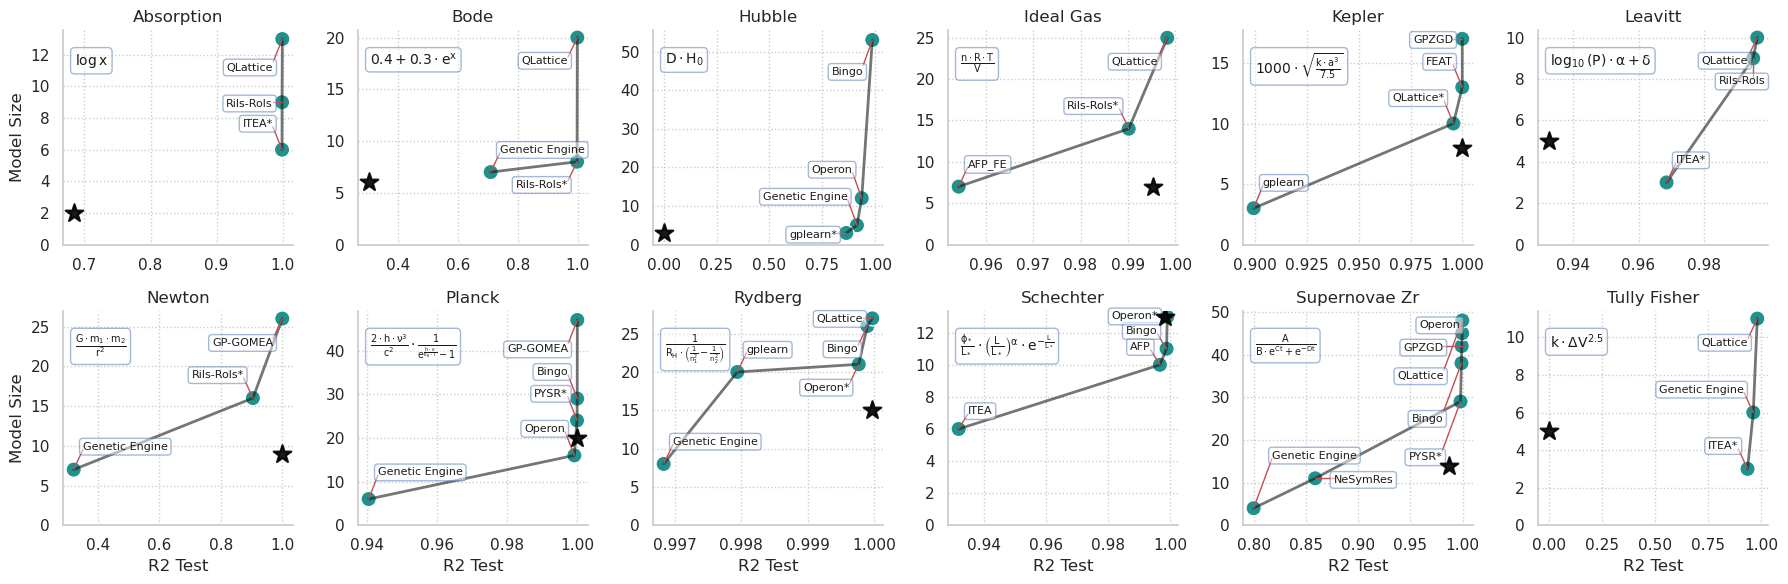

In [11]:
def prepare_pareto_data(
    df_sum,
    estimator=np.median,
    facet_column='dataset',
    xcol='r2_test_rank',
    ycol='model_size_rank',
):
    """Compute aggregated Pareto data and ranks for each dataset."""

    # Determine optimization direction (the `front` method expects minimization objectives)
    is_max_metric = lambda s: not any(k in s for k in ['rank', 'size', 'mse'])
    x_greater_is_better = is_max_metric(xcol)
    y_greater_is_better = is_max_metric(ycol)

    # Aggregate numeric columns only
    numeric_cols = df_sum.select_dtypes('number').columns
    grouped = (
        df_sum.groupby(['algorithm', facet_column])[numeric_cols]
        .agg(estimator)
        .reset_index()
    )

    data = grouped[['algorithm', facet_column, xcol, ycol]].copy()
    levels = len(data['algorithm'].unique())
    pareto_ranks = np.ones(len(data)) * levels

    # Compute Pareto fronts per facet
    for val in data[facet_column].unique():
        objs = data[data[facet_column] == val].copy()
        if x_greater_is_better:
            objs.loc[:, xcol] = -objs[xcol]
        if y_greater_is_better:
            objs.loc[:, ycol] = -objs[ycol]

        for level in range(levels):
            if not np.any(np.isfinite(objs[[xcol, ycol]])):
                break
            PF = front(objs[xcol].values, objs[ycol].values)
            if len(PF) > 0:
                pareto_ranks[objs.iloc[PF].index] = level
            objs.iloc[PF, :] = np.inf

    data['pareto_rank'] = pareto_ranks
    return data


def plot_pareto_facets(
    df_sum,
    data,
    estimator=np.median,
    plot_error=True,
    levels_to_show=1,
    facet_column='dataset',
    xcol='r2_test_rank',
    ycol='model_size_rank',
):
    """Plot Pareto fronts per dataset using a FacetGrid layout."""

    levels_to_show = np.minimum(levels_to_show, len(data['pareto_rank'].unique()))

    # Initialize facet_grid
    cmap = sns.color_palette("viridis", n_colors=levels_to_show)
    g = sns.FacetGrid(
        data,
        col=facet_column,
        height=3,
        aspect=1,
        col_wrap=6,
        margin_titles=True,
        sharex=False,
        sharey=False,
    )

    pareto_optimal_solutions = [] # stores the closest solution to the groundtruth
    def custom_plot(data, **kwargs):
        ax = sns.scatterplot(
            data=data[data['pareto_rank'] < levels_to_show],
            x=xcol,
            y=ycol,
            hue='pareto_rank',
            s=120,
            palette=cmap,
            legend=False,
            ax=kwargs.get('ax'),
        )

        # Plot Pareto front lines
        styles = ['-', '-.', '--'] + [':']*np.maximum(0, levels_to_show-3)
        for level in range(levels_to_show):
            pf_points = data[data['pareto_rank'] == level].sort_values(by=[xcol, ycol])
            if len(pf_points):
                ax.plot(pf_points[xcol], pf_points[ycol], styles[level % len(styles)] + 'k',
                        alpha=0.6, lw=2, zorder=1)

        # Optional: bootstrap confidence intervals
        if plot_error:
            for alg, sub in data.groupby('algorithm'):
                subset = df_sum[
                    (df_sum['algorithm'] == alg) &
                    (df_sum[facet_column] == sub[facet_column].iloc[0])
                ]
                if len(subset) <= 1:
                    continue

                if sub['pareto_rank'].iloc[0] >= levels_to_show:
                    continue

                _, sdx, ciux, cilx = bootstrap(subset[xcol].values, fn=estimator, n=1000)
                _, sdy, ciuy, cily = bootstrap(subset[ycol].values, fn=estimator, n=1000)

                color = cmap[int(sub['pareto_rank'].iloc[0])]
                xval, yval = sub[xcol].iloc[0], sub[ycol].iloc[0]

                ax.plot([cilx, ciux], [yval, yval], color=color, alpha=0.5, lw=2, zorder=-10)
                ax.plot([xval, xval], [cily, ciuy], color=color, alpha=0.5, lw=2, zorder=-10)

        # Plot ground-truth / first-principles heuristic (if available)
        # fs_data should be a dict keyed by dataset name with xcol,ycol and optional 'latex_eq'
        ds_name = data[facet_column].values[0]
        if 'fs_data' in globals() and ds_name in fs_data:
            truth = fs_data[ds_name]
            if xcol in truth and ycol in truth:
                ax.scatter(truth[xcol], truth[ycol],
                           marker='*',
                           color='black',
                           s=180,
                           linewidth=1.5,
                           alpha=0.9,
                           zorder=5)
                # optional latex eq text in corner if provided
                if 'latex_eq' in truth:
                    ax.text(
                        0.05, 0.9, truth['latex_eq'],
                        color="k", fontsize=10,
                        horizontalalignment="left", verticalalignment="top",
                        transform=ax.transAxes,
                        bbox=dict(facecolor='w', edgecolor='b', boxstyle='round', alpha=0.5)
                    )

        # Add labels (algorithm names). collect points to label with ta.allocate
        ta_x, ta_y, ta_text = [], [], []
        for idx, row in data.iterrows():
            if row['pareto_rank'] < levels_to_show:
                ta_x.append(row[xcol])
                ta_y.append(row[ycol])
                ta_text.append(row['algorithm'])

        # Find and mark the solution closest to ground-truth (if fs_data exists)
        if 'fs_data' in globals() and ds_name in fs_data and len(ta_x) > 0:
            t_x = fs_data[ds_name][xcol]
            t_y = fs_data[ds_name][ycol]

            # normalize to 0-1 using pareto candidates span (avoid zero-division)
            x_min, x_max = min(ta_x), max(ta_x)
            y_min, y_max = min(ta_y), max(ta_y)
            if x_max == x_min:
                norm_x = np.zeros(len(ta_x))
                norm_tx = 0.0
            else:
                norm_x = [(xi - x_min) / (x_max - x_min) for xi in ta_x]
                norm_tx = (t_x - x_min) / (x_max - x_min)
            if y_max == y_min:
                norm_y = np.zeros(len(ta_y))
                norm_ty = 0.0
            else:
                norm_y = [(yi - y_min) / (y_max - y_min) for yi in ta_y]
                norm_ty = (t_y - y_min) / (y_max - y_min)

            distances = np.sqrt((np.array(norm_x) - norm_tx) ** 2 + (np.array(norm_y) - norm_ty) ** 2)
            closest_idx = int(np.argmin(distances))
            # special-case from original code: pick second-closest for a particular dataset (kept for parity)
            if ds_name == 'first_principles_bode' and len(distances) > 1:
                closest_idx = int(np.argsort(distances)[1])

            # append symbolic model if present in df_sum (take last if multiple)
            chosen_alg = ta_text[closest_idx]
            try:
                symbolic_model = str(df_sum[(df_sum['algorithm'] == chosen_alg) & (df_sum[facet_column] == ds_name)]['symbolic_model'].values[-1])
            except Exception:
                symbolic_model = ''

            pareto_optimal_solutions.append({
                'algorithm': chosen_alg,
                'dataset': ds_name,
                xcol: ta_x[closest_idx],
                ycol: ta_y[closest_idx],
                'symbolic_model': symbolic_model
            })

            # mark the chosen label with a star
            ta_text[closest_idx] = ta_text[closest_idx] + '*'

        # allocate labels with 'ta' (label allocator). If ta is not available, fall back to simple text
        if 'ta' in globals():
            try:
                ta.allocate(
                    ax, ta_x, ta_y, ta_text,
                    min_distance=0.04 if ds_name != 'first_principles_supernovae_zr' else 0.08,
                    avoid_label_lines_overlap=True,
                    avoid_crossing_label_lines=True,
                    x_scatter=np.array(ta_x) + ( [fs_data[ds_name][xcol]] if ('fs_data' in globals() and ds_name in fs_data) else [] ),
                    y_scatter=np.array(ta_y) + ( [fs_data[ds_name][ycol]] if ('fs_data' in globals() and ds_name in fs_data) else []),
                    textsize=8, rotation=0,
                    **{"bbox": dict(facecolor='w', edgecolor='b', boxstyle='round', alpha=0.5)}
                )
            except Exception:
                # fallback to simple text labels if ta fails
                for xx, yy, tt in zip(ta_x, ta_y, ta_text):
                    ax.text(xx, yy, tt, fontsize=7, rotation=-20, ha='center', va='bottom')
        else:
            for xx, yy, tt in zip(ta_x, ta_y, ta_text):
                ax.text(xx, yy, tt, fontsize=7, rotation=-20, ha='center', va='bottom')

        ax.set_ylim(0, None)
        ax.grid(ls=":")
        return ax

    g.map_dataframe(custom_plot, col=facet_column)

    # Format titles and labels (we have 12 datasets, lets use 2 rows)
    for i, (title, ax) in enumerate(g.axes_dict.items()):
        ax.set_title(title.replace('first_principles_', '').replace('_', ' ').title())
        if i % 6 == 0:
            ax.set_ylabel(ycol.replace('_', ' ').title())
        else:
            ax.set_ylabel('')
        if i >= 6:
            ax.set_xlabel(xcol.replace('_', ' ').replace('zero ', '').title())
        else:
            ax.set_xlabel('')

    plt.tight_layout()
    save(name=f"pareto_facets_{xcol}_{ycol}")
    return g, pareto_optimal_solutions

# =========================== Generating paper plot ===========================

# Filter and preprocess your data
df_results_plot = df_results.copy()
df_results_plot = df_results_plot[
    ~df_results_plot['algorithm'].isin(['Genetic Engine rs', 'Genetic Engine hc', 'Genetic Engine 1p1'])
]
df_results_plot = df_results_plot[
    ~df_results_plot['dataset'].isin(['first_principles_supernovae_zg'])
]
df_results_plot = df_results_plot[df_results_plot['model_size'] > 1]

# Select best r2 per algorithm-dataset pair
best_idx = df_results_plot.groupby(['algorithm', 'dataset'])['r2_zero_test'].transform(max) == df_results_plot['r2_zero_test']
df_results_plot = df_results_plot[best_idx]

# Compute Pareto data and plot
pareto_data = prepare_pareto_data(
    df_results_plot,
    estimator=np.median,
    xcol='r2_zero_test',
    ycol='model_size'
)

g, pareto_optimal_solutions = plot_pareto_facets(
    df_sum=df_results_plot,
    data=pareto_data,
    estimator=np.median,
    plot_error=True,
    levels_to_show=1,
    xcol='r2_zero_test',
    ycol='model_size'
)


In [7]:
pareto_data.to_csv('../figs/first-principles-tuning/pareto_data.csv', index=False)
display(pareto_data)

pareto_optimal_solutions = pd.DataFrame().from_records(pareto_optimal_solutions)
pareto_optimal_solutions.to_csv('../figs/first-principles-tuning/pareto_optimal_solutions.csv', index=False)
display(pareto_optimal_solutions)

,algorithm,dataset,r2_zero_test,model_size,pareto_rank
0,AFP,first_principles_absorption,0.998451,15.0,3.0
1,AFP,first_principles_bode,0.987223,37.0,4.0
2,AFP,first_principles_hubble,0.930206,55.0,1.0
3,AFP,first_principles_ideal_gas,0.989328,17.0,1.0
4,AFP,first_principles_kepler,0.999694,20.0,2.0
...,...,...,...,...,...
271,gplearn,first_principles_planck,0.617429,25.0,3.0
272,gplearn,first_principles_rydberg,0.997943,20.0,0.0
273,gplearn,first_principles_schechter,0.991252,26.0,6.0
274,gplearn,first_principles_supernovae_zr,0.965330,53.0,3.0


,algorithm,dataset,r2_zero_test,model_size,symbolic_model
0,ITEA,first_principles_absorption,0.998943,6.0,0.2404329426535737 + 1.7619868596981292*Tanh(X...
1,Rils-Rols,first_principles_bode,0.998434,8.0,0.346632*exp(1.51515151515152*n) - 0.875055
2,gplearn,first_principles_hubble,0.864021,3.0,"Add(0.090, D)"
3,Rils-Rols,first_principles_ideal_gas,0.990167,14.0,0.69868*log(n + 1.641593) - 0.894298 + 0.48482...
4,QLattice,first_principles_kepler,0.995693,10.0,1.98831*tanh(0.662314*a - 0.563921) + 0.786957
5,ITEA,first_principles_leavitt,0.968607,3.0,-1.6683022262011568e-15 + -0.9414267360031622*...
6,Rils-Rols,first_principles_newton,0.904353,16.0,0.346018*m1/(0.831935*m2 - 0.096902051139/m1) ...
7,PYSR,first_principles_planck,0.999913,24.0,0.0238853581371*log(sqrt(nu + 0.38070464010263...
8,Operon,first_principles_rydberg,0.999766,21.0,((-0.003981) + (1.006104 * (exp((exp(((1.73041...
9,Operon,first_principles_schechter,0.999137,13.0,(0.748051 + ((-0.274735) * (log(((163.992065 *...


In [8]:
pareto_optimal_solutions_df = pd.DataFrame(pareto_optimal_solutions)
with pd.option_context("max_colwidth", 1000):
    print(pareto_optimal_solutions_df.replace({'first_principles_':''}, regex=True).sort_values('dataset').round(2).style.to_latex())

\begin{tabular}{lllrrl}
 & algorithm & dataset & r2_zero_test & model_size & symbolic_model \\
0 & ITEA & absorption & 1.000000 & 6.000000 & 0.2404329426535737 + 1.7619868596981292*Tanh(Xaxis0) \\
1 & Rils-Rols & bode & 1.000000 & 8.000000 & 0.346632*exp(1.51515151515152*n) - 0.875055 \\
2 & gplearn & hubble & 0.860000 & 3.000000 & Add(0.090, D) \\
3 & Rils-Rols & ideal_gas & 0.990000 & 14.000000 & 0.69868*log(n + 1.641593) - 0.894298 + 0.484826100514623495304*exp(-V) \\
4 & QLattice & kepler & 1.000000 & 10.000000 & 1.98831*tanh(0.662314*a - 0.563921) + 0.786957 \\
5 & ITEA & leavitt & 0.970000 & 3.000000 & -1.6683022262011568e-15 + -0.9414267360031622*(logP) \\
6 & Rils-Rols & newton & 0.900000 & 16.000000 & 0.346018*m1/(0.831935*m2 - 0.096902051139/m1) + 1.138212 \\
7 & PYSR & planck & 1.000000 & 24.000000 & 0.0238853581371*log(sqrt(nu + 0.380704640102635) - 0.04003873) + 0.412260363794255 - 0.315558*(nu + 0.38472152)/(T + 0.94697434) \\
8 & Operon & rydberg & 1.000000 & 21.000000 &